In [1]:
## In this version we clean the code and try to make is 2D 
## Date: 28 June 2023

In [2]:
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable

import sys
import platform
import matplotlib.pyplot as plt

from numpy.fft  import fft, ifft,fft2, ifft2,fftn, ifftn
from scipy import signal
import os
import scipy
import time

from math import pi as PI
has_gpu = torch.cuda.is_available()
has_mps = torch.backends.mps.is_built()
device = "mps" if torch.backends.mps.is_built() \
    else "cuda:0" if torch.cuda.is_available() else "cpu"

print(f"Python Platform: {platform.platform()}")
print(f"PyTorch Version: {torch.__version__}")

# print(f"Scikit-Learn {sk.__version__}")
print("GPU is", "available" if has_gpu else "NOT AVAILABLE")
print("MPS (Apple Metal) is", "AVAILABLE" if has_mps else "NOT AVAILABLE")
print(f"Target device is {device}")

Python Platform: Windows-11-10.0.26100-SP0
PyTorch Version: 2.6.0+cu124
GPU is available
MPS (Apple Metal) is NOT AVAILABLE
Target device is cuda:0


## Defining the Neural Network

In [3]:
'''class Net(nn.Module):
    def __init__(self,num_neurons=32):
        super(Net, self).__init__()       
        self.num_neurons = 32        
        self.hidden_layer1 = nn.Linear(4,num_neurons) # 2# number of input
        self.hidden_layer2 = nn.Linear(num_neurons,num_neurons)
        self.hidden_layer3 = nn.Linear(num_neurons,num_neurons)
        # self.hidden_layer4 = nn.Linear(num_neurons,num_neurons)
        # self.hidden_layer5 = nn.Linear(num_neurons,num_neurons)
        self.output_layer = nn.Linear(num_neurons,5) ## Incorporating two outputs rho and velocity'''

class Net(nn.Module):
    def __init__(self, num_neurons=32):
        super(Net, self).__init__()
        self.num_neurons = num_neurons

        self.input_layer_2d = nn.Linear(2, num_neurons)  # x, t
        self.input_layer_3d = nn.Linear(3, num_neurons)  # x, y, t
        self.input_layer_4d = nn.Linear(4, num_neurons)  # x, y, z, t

        self.hidden_layer2 = nn.Linear(num_neurons, num_neurons)
        self.hidden_layer3 = nn.Linear(num_neurons, num_neurons)

        self.output_layer_2d = nn.Linear(num_neurons, 3)  # For x, t
        self.output_layer_3d = nn.Linear(num_neurons, 4)  # For x, y, t
        self.output_layer_4d = nn.Linear(num_neurons, 5)  # For x, y, z, t

    def forward(self,X):
        x, t = X[0],X[-1]

        if len(X) == 2:
            inputs = torch.cat([x, t], dim=1)
            layer1_out = self.input_layer_2d(inputs)
        elif len(X) == 3:
            y = X[1]
            inputs = torch.cat([x, y, t], dim=1)
            layer1_out = self.input_layer_3d(inputs)
        elif len(X) == 4:
            y = X[1]
            z = X[2]
            inputs = torch.cat([x, y, z, t], dim=1)
            layer1_out = self.input_layer_4d(inputs)
        else:
            raise ValueError(f"Expected len(X) in [2, 3, 4] but got {len(X)}")

        layer2_out = torch.sin(self.hidden_layer2(layer1_out))
        layer3_out = torch.sin(self.hidden_layer3(layer2_out))
        # layer4_out = torch.sin(self.hidden_layer4(layer3_out))
        # layer5_out = torch.sin(self.hidden_layer5(layer4_out))
        if len(X) == 2:
            output = self.output_layer_2d(layer3_out)
        elif len(X) == 3:
            output = self.output_layer_3d(layer3_out)
        else:
            output = self.output_layer_4d(layer3_out)

        return output   


# class Net(nn.Module):
#     def __init__(self,num_input=1,num_output=1,num_neurons=32,num_layers=2,actv=nn.Tanh):
#         super(Net, self).__init__()
#         self.num_input= num_input
#         self.num_output= num_output
#         self.num_neurons = num_neurons
#         self.num_layers = num_layers
#         self.actv = actv
        
#         layers = []
#         # input layer
#         layers.append(nn.Linear(self.num_input,self.num_neurons))
#         print(type(layers))
        
#         # hidden layers with linear layer and activation
#         for _ in range(num_layers):            
#             layers.append(nn.Linear(self.num_neurons, self.num_neurons))
#             layers.append(torch.sin(layers))
#         # output layer
#         layers.append(nn.Linear(self.num_neurons, self.num_output))

#         # build the network
#         self.network = nn.Sequential(*layers)
        
 
# net = Net() #num_input=4,num_output=5
# net = net.to(device)

# net


In [17]:
def diff(u,var,order=1):
    
    """ The derivative of a variable with respect to another.

        :param u: The :math:`u` in :math:`\displaystyle\frac{\partial u}{\partial t}`.
        :type u: `torch.Tensor`
        :param t: The :math:`t` in :math:`\displaystyle\frac{\partial u}{\partial t}`.
        :type t: `torch.Tensor`
        :param order: The order of the derivative, defaults to 1.
        :type order: int
        :returns: The derivative evaluated at ``t``.
        :rtype: `torch.Tensor`
    """
    
    u.requires_grad_()
    var.requires_grad_()
    ones = torch.ones_like(u)
    der, = torch.autograd.grad(u, var, create_graph=True, grad_outputs=ones, allow_unused=True)
    if der is None:
        return torch.zeros_like(var, requires_grad=True)
    else:
        der.requires_grad_()
    for i in range(1, order):
        ones = torch.ones_like(der)
        der, = torch.autograd.grad(der, var, create_graph=True, grad_outputs=ones, allow_unused=True)
        if der is None:
            return torch.zeros_like(var, requires_grad=True)
        else:
            der.requires_grad_()
    return der


class col_gen(object):

    def __init__(self,rmin=[0,0,0,0],rmax=[1,1,1,1], N_0 = 1000,N_b=1000,N_r = 3000, dimension=1):
        
        '''
        This function accepts the range of the computational domain and returns the collocation points depending on the dimension

        xmin=0, xmax=1,: Default is seto to 0 and 1 for xmin and xmax respestively 
        ymin=0, ymax=0 : Default is set is to 0 when only dimension 1 is used
        zmin=0, zmax=0 : Default is set is to 0 when only dimension 1 & 2 is used
        tmin=0, tmax=1 : Default is set is to 0 and 1 
        N_0: Number of collocation points for the IC Default is set to 1000
        N_B: Number of collocation points for the main Domain: Default is set to 1000
        N_r: Number of collocation points for the main Domain: Default is set to 3000
        dimension : Spacial Dimension
               
        
        '''
    
        self.rmin = rmin
        self.rmax = rmax
        self.N_0 = N_0
        self.N_b = N_b
        self.N_r = N_r
        self.dimension = dimension
        
        
    def geo_time_coord(self,option,coordinate=1):
        '''
        option: Takes arguments: "Domain", "BC" for Boundary conditions, "IC" for initial conditions:
        
        '''
        
        if self.dimension == 1: 
            if option == "Domain":
                coor = []
                x_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_coor)
                t_coor = t_collocation=torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[1], self.rmax[1]).requires_grad_()
                coor.append(t_coor)

                return coor

            if option == "IC": ## Intial conditions collocation points

                coor = []
                x_0 = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_0)

                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)

                return coor

            if option == "BC":
                coor_l = []
                coor_r = []
                x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])

                coor_l.append(x_bc_l)
                coor_l.append(t_bc)

                coor_r.append(x_bc_r)
                coor_r.append(t_bc)

                return  coor_l, coor_r
            
        if self.dimension == 2:
            if option == "Domain":
                
                coor = []
                for d in range(self.dimension+1): ## +1 for the time dimension
                    temp_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)

                return coor
            
            if option == "IC": ## Intial conditions collocation points
                coor = []
                for d in range(self.dimension): ## time is zero as it is the initial condition
                    temp_coor = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)

                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)

                return coor
            
            if option == "BC":
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])
                t_bc.requires_grad_()
        
                if coordinate == 1: 
                    
                    x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()                   
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc_l)
                    coor_l.append(y_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc_r)
                    coor_r.append(y_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r
                   
                 
                if coordinate == 2:
                    y_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    y_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()            
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc_l)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc_r)
                    coor_r.append(t_bc)
                    
                    return coor_l, coor_r
    
            
        if self.dimension == 3: 
            if option == "Domain":
                
                coor = []
                for d in range(self.dimension+1): ## +1 for the time dimension
                    temp_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)
                
                return coor

            if option == "IC": ## Intial conditions collocation points
                coor = []
                for d in range(self.dimension): ## time is zero as it is the initial condition                  
                    temp_coor = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)
                
                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)
                
                return coor
             

            if option == "BC":                
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])
                t_bc.requires_grad_()
        
                if coordinate == 1: 
                    
                    x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()                   
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                    z_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate+1], self.rmax[coordinate+1]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc_l)
                    coor_l.append(y_bc)
                    coor_l.append(z_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc_r)
                    coor_r.append(y_bc)
                    coor_r.append(z_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r
                   
                 
                if coordinate == 2:
                    y_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    y_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()            
                    z_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc_l)
                    coor_l.append(z_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc_r)
                    coor_r.append(z_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l, coor_r
                    
                   
                if coordinate == 3:
                    
                    z_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    z_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-3], self.rmax[coordinate-3]).requires_grad_()
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc)
                    coor_l.append(z_bc_l)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc)
                    coor_r.append(z_bc_r)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r

                    
class ASTPN(col_gen):  
    
    def __init__(self, rmin=[0,0,0,0], rmax=[1,1,1,1], N_0 = 1000, N_b=1000, N_r=3000, dimension=1):
        super().__init__(rmin,rmax, N_0,N_b,N_r, dimension)
        
       
        self.coord_Lx, self.coord_Rx = self.geo_time_coord(option="BC",coordinate=1)
        
        if dimension == 2:
            self.coord_Ly, self.coord_Ry = self.geo_time_coord(option="BC",coordinate=2)

        if dimension == 3:
            self.coord_Ly, self.coord_Ry = self.geo_time_coord(option="BC",coordinate=2)
            self.coord_Lz, self.coord_Rz = self.geo_time_coord(option="BC",coordinate=3)
    
    
    
    def periodic_BC(self,net,coordinate=1,derivative_order=0,component=0):
        
        '''
           INPUT: geomtime: The collocatin grids
           since it is BC the derivative always wrt to spacial coordinate: coordinate =1 is the first x coordinate
           derivative order: what order derivative
           component: output component's derivative is taken component = 0 is the First output fron the network
           default is set to 0,i.e., the first output
           coordinate : 1: xaxis (default), 2: with y axis 3: with zaxis
         '''

        if coordinate==1:   
            coord_L, coord_R = self.coord_Lx, self.coord_Rx
        if coordinate==2:       
            coord_L, coord_R = self.coord_Ly, self.coord_Ry
        if coordinate==3:       
            coord_L, coord_R = self.coord_Lz, self.coord_Rz
        
        
        # return coord_L, coord_R
          
        variable_l = net(coord_L)[:,component:component+1] 
        variable_r = net(coord_R)[:,component:component+1] 
        
        if derivative_order == 0:
            return torch.mean((variable_l - variable_r)**2)

        elif derivative_order == 1:        
            der_l = diff(variable_l,coord_L[coordinate-1],order=derivative_order)
            der_r = diff(variable_r,coord_R[coordinate-1],order=derivative_order)
            
            return torch.mean((der_l-der_r)**2)


    


# ######### Residue from the PDEs##########

# def pde_residue(x,t,net):
    
#     '''
#     This is the main function that returns all the PDE residue
#     '''
    
#     net_outputs = net(x,t)
    
    
#     rho, v, phi = net_outputs[:,0:1], net_outputs[:,1:2], net_outputs[:,2:3]
#     rho_x = diff(rho,x,order=1)
#     rho_t = diff(rho,t,order=1)
    
#     v_x = diff(v,x,order=1)
#     v_t = diff(v,t,order=1)
    
#     phi_x = diff(phi,x,order=1)
#     phi_x_x = diff(phi,x,order=2)

    
#     ## The residues from the equations
#     rho_r = rho_t + v * rho_x + rho * v_x
#     v_r = rho_t*v +rho*v_t + rho_x*v*v + rho*v_x*v + rho*v*v_x  + cs*cs*rho_x + rho*phi_x    
#     phi_r = phi_x_x - const*(rho - rho_o)
    
#     return rho_r,v_r,phi_r


def pde_residue(colloc, net, dimension = 1):
    
    '''
    This is the main function that returns all the PDE residue
    '''
    net_outputs = net(colloc)
    
    x = colloc[0]#, t = colloc[-1]
    if dimension == 1:
        t = colloc[1]
    elif dimension == 2:
        y = colloc[1]
        t = colloc[2]
    elif dimension == 3:
        y = colloc[1]
        z = colloc[2]
        t = colloc[3]
    
    rho, vx = net_outputs[:,0:1], net_outputs[:,1:2]

    if dimension == 1:

        phi = net_outputs[:,2:3]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)

        vx_t = diff(vx, t,order=1)
        vx_x = diff(vx, x,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

    elif dimension == 2:

        vy = net_outputs[:,2:3]
        phi = net_outputs[:,3:4]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)
        rho_y = diff(rho,y,order=1)

        vx_t = diff(vx, t,order=1)
        vy_t = diff(vy, t,order=1)

        vx_x = diff(vx, x,order=1)
        vx_y = diff(vx, y,order=1)
        vy_x = diff(vy, x,order=1)
        vy_y = diff(vy, y,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

        phi_y = diff(phi,y,order=1)
        phi_y_y = diff(phi,y,order=2)

    elif dimension == 3:
        vy = net_outputs[:,2:3]
        vz = net_outputs[:,3:4]
        phi = net_outputs[:,4:5]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)
        rho_y = diff(rho,y,order=1)
        rho_z = diff(rho,z,order=1)

        vx_t = diff(vx, t,order=1)
        vy_t = diff(vy, t,order=1)
        vz_t = diff(vz, t,order=1)

        vx_x = diff(vx, x,order=1)
        vy_x = diff(vy, x,order=1)
        vz_x = diff(vz, x,order=1)

        vx_y = diff(vx, y,order=1)
        vy_y = diff(vy, y,order=1)
        vz_y = diff(vz, y,order=1)
        
        vx_z = diff(vx, z,order=1)
        vy_z = diff(vy, z,order=1)
        vz_z = diff(vz, z,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

        phi_y = diff(phi,y,order=1)
        phi_y_y = diff(phi,y,order=2)
    
        phi_z = diff(phi,z,order=1)
        phi_z_z = diff(phi,z,order=2)

    
    ## The residues from the equations

    if dimension == 1:
        rho_r = rho_t + vx * rho_x + rho * vx_x
        vx_r = rho*vx_t + rho*(vx*vx_x) + cs*cs*rho_x +rho*phi_x
        phi_r = phi_x_x - const*(rho - rho_o)

        return rho_r, vx_r, phi_r

    elif dimension == 2:
        rho_r = rho_t + vx * rho_x + vy * rho_y + rho * vx_x + rho * vy_y
        vx_r = rho*vx_t + rho*(vx*vx_x + vy*vx_y) + cs*cs*rho_x +rho*phi_x
        vy_r = rho*vy_t + rho*(vy*vy_y + vx*vy_x) + cs*cs*rho_y +rho*phi_y
        phi_r = phi_x_x + phi_y_y - const*(rho - rho_o)

        return rho_r, vx_r, vy_r, phi_r
    
    elif dimension == 3:
        rho_r = rho_t + vx * rho_x + rho * vx_x + vy *rho_y + rho * vy_y + vz *rho_z +rho * vz_z
        vx_r = rho*vx_t + rho*(vx*vx_x + vy*vx_y+vz*vx_z) + cs*cs*rho_x +rho*phi_x
        vy_r = rho*vy_t + rho*(vy*vy_y + vx*vy_x+vz*vy_z) + cs*cs*rho_y +rho*phi_y
        vz_r = rho*vz_t + rho*(vz*vz_z + vx*vz_x+vy*vz_y) + cs*cs*rho_z +rho*phi_z
        phi_r = phi_x_x + phi_y_y +phi_z_z - const*(rho - rho_o)
        
        return rho_r,vx_r,vy_r,vz_r,phi_r


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\tirth\AppData\Local\Temp\ipykernel_132312\3087813753.py:3: SyntaxWarning: invalid escape sequence '\d'
  """ The derivative of a variable with respect to another.


In [15]:
## Setting up the problem

lam = 7.0          # one wavelength
num_of_waves = 3
cs = 1.0          # % Sound Speed

rho_1 = .03        # question 2a linear wave propagation
rho_o = 1          # zeroth order density
const = 1          ## we set 4 pi G  to 1
G = 1

'''output_folder = "1D_fig" 


try:
    os.makedirs(output_folder)
except OSError:
    print ("Creation of the directory %s failed/ not needed as it already exit" % output_folder)
else:
    print ("Successfully created the directory %s" % output_folder)'''
  

jeans = np.sqrt(4*PI**2*cs**2/(const*G*rho_o))

if lam> jeans:
    alpha = np.sqrt(const*G*rho_o-cs**2*(2*PI/lam)**2)
else:
    alpha = np.sqrt(cs**2*(2*PI/lam)**2 - const*G*rho_o)
    
# v_1 = (cs*rho_1)/rho_o # velocity perturbation without gravity
v_1  = (rho_1/rho_o) * (alpha/(2*PI/lam)) ## With gravity


def fun_rho_0(x):
    ''' Define initial condition for density Returning Eq (11a)'''
    # print('wavelength',lam)
    rho_0 = rho_o + rho_1 * torch.cos(2*PI*x[0]/lam)    
    return rho_0

def fun_v_0(x):
    '''initial condition for velocity -- Returning Eq 11b'''
    
    if lam > jeans:
        v_0 = - v_1 * torch.sin(2*PI*x[0]/lam)## This is for sound wave ## refer to the paper for details
    else:
        v_0 = v_1 * torch.cos(2*PI*x[0]/lam)  ## This is for the gravity wave
    return v_0

def func(x):
    return x[0]*0

## Model INITIALIZATION

In [20]:
# Set boundary
tmin = 0.
tmax = 2.
xmin = 0.
xmax = xmin+lam*num_of_waves
ymin= 0 
ymax= 1
zmin= 0 
zmax= 1

cs = 1.

N_0 = 10000
N_b = 10000
N_r = 40000

net = Net()
net = net.to(device)
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters(),lr=0.001,)
optimizerL = torch.optim.LBFGS(net.parameters(),line_search_fn='strong_wolfe')

'''coor_l, coor_r = model.geo_time_coord(option="BC", coordinate=1)

# Print the lengths and values of coor_l and coor_r
print("Length of coor_l:", len(coor_l))
print("Length of coor_r:", len(coor_r))
print("coor_l:", coor_l)
print("coor_r:", coor_r)'''

model_1D = ASTPN(rmin=[xmin,ymin,zmin,tmin],rmax=[xmax,ymax,zmax,tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=1)
model_2D = ASTPN(rmin=[xmin,ymin,zmin,tmin],rmax=[xmax,ymax,zmax,tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=2)
model_3D = ASTPN(rmin=[xmin,ymin,zmin,tmin],rmax=[xmax,ymax,zmax,tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=3)

collocation_domain_1D = model_1D.geo_time_coord(option= "Domain") 
collocation_IC_1D = model_1D.geo_time_coord(option= "IC")

collocation_domain_2D = model_2D.geo_time_coord(option= "Domain")
collocation_IC_2D = model_2D.geo_time_coord(option= "IC")

collocation_domain_3D = model_3D.geo_time_coord(option= "Domain")
collocation_IC_3D = model_3D.geo_time_coord(option= "IC")

#print(len(collocation_domain), len(collocation_IC))

#print(min(collocation_domain[:,0:1]),np.shape(collocation_domain[:,0:1]))
#print(min(collocation_domain[:,1:2]),np.shape(collocation_domain[:,0:1]))
#print(min(collocation_domain[:,2:3]),np.shape(collocation_domain[:,0:1]))


#print(max(collocation_IC [:,0:1]),np.shape(collocation_IC [:,0:1]))
#print(min(collocation_IC [2]),np.shape(collocation_IC [2]))
#collocation_IC[3]

In [7]:
'''coordinate = 2
test = model.periodic_BC(net,coordinate=coordinate,derivative_order=0,component=0)
print(test.item())

test_1 = model.periodic_BC(net,coordinate=coordinate,derivative_order=1,component=0)
print(test_1.item())'''

'coordinate = 2\ntest = model.periodic_BC(net,coordinate=coordinate,derivative_order=0,component=0)\nprint(test.item())\n\ntest_1 = model.periodic_BC(net,coordinate=coordinate,derivative_order=1,component=0)\nprint(test_1.item())'

In [21]:
### (3) Training / Fitting
from tqdm import tqdm
iteration_adam = 1000
iterationL = 2000

#start = time.time()
def closure(model, collocation_domain, collocation_IC):

    ############## Loss based on initial conditions ###############
    rho_0 = fun_rho_0(collocation_IC)
    vx_0  = fun_v_0(collocation_IC)

    if model.dimension == 2:
        vy_0  = func(collocation_IC)

    elif model.dimension == 3:
        vy_0  = func(collocation_IC)
        vz_0  = func(collocation_IC)
    
    net_ic_out = net(collocation_IC)

    rho_ic_out = net_ic_out[:,0:1]
    vx_ic_out  = net_ic_out[:,1:2]

    if model.dimension == 2:
        vy_ic_out  = net_ic_out[:,2:3]
    elif model.dimension == 3:
        vy_ic_out  = net_ic_out[:,2:3]
        vz_ic_out  = net_ic_out[:,3:4]

    mse_rho_ic =  mse_cost_function(rho_ic_out, rho_0)
    mse_vx_ic  =  mse_cost_function(vx_ic_out, vx_0)

    if model.dimension == 2:
        mse_vy_ic  =  mse_cost_function(vy_ic_out, vy_0)

    elif model.dimension == 3:
        mse_vy_ic  =  mse_cost_function(vy_ic_out, vy_0)
        mse_vz_ic  =  mse_cost_function(vz_ic_out, vz_0)

    ############# Loss based on boundary conditions #################

    
    rhox_b     = model.periodic_BC(net,coordinate=1,derivative_order=0,component=0)
    
    vx_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=1)
       
    phi_xb     = model.periodic_BC(net,coordinate=1,derivative_order=0,component=2)
    phi_xx_b   = model.periodic_BC(net,coordinate=1,derivative_order=1,component=2)

    if model.dimension == 2 or model.dimension == 3:
        rhoy_b     = model.periodic_BC(net,coordinate=2,derivative_order=0,component=0)

        vx_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=1)
        vy_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=2)
        vy_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=2)

        phi_yb     = model.periodic_BC(net,coordinate=2,derivative_order=0,component=3)
        phi_yy_b   = model.periodic_BC(net,coordinate=2,derivative_order=1,component=3)

        if model.dimension == 3:
            rhoz_b     = model.periodic_BC(net,coordinate=3,derivative_order=0,component=0)

            vx_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=1)
            vy_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=2)
            vy_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=2)
    
            vz_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=3)
            vz_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=3)
            vz_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=3)

            phi_zb     = model.periodic_BC(net,coordinate=3,derivative_order=0,component=4)
            phi_zz_b   = model.periodic_BC(net,coordinate=3,derivative_order=1,component=4)


    ############## Loss based on PDE ###################################
    
    if model.dimension == 1:
        rho_r,vx_r,phi_r = pde_residue(collocation_domain, net, dimension = 1)

    elif model.dimension == 2:
        rho_r,vx_r,vy_r,phi_r = pde_residue(collocation_domain, net, dimension = 2)

    elif model.dimension == 3:
        rho_r,vx_r,vy_r,vz_r,phi_r = pde_residue(collocation_domain, net, dimension = 3)
    

    mse_rho  = torch.mean(rho_r ** 2)
    mse_velx = torch.mean(vx_r  ** 2)

    if model.dimension == 2:
        mse_vely = torch.mean(vy_r  ** 2)

    elif model.dimension == 3:
        mse_vely = torch.mean(vy_r  ** 2)
        mse_velz = torch.mean(vz_r  ** 2)
    
    mse_phi  = torch.mean(phi_r ** 2)

    ################### Combining the loss functions ####################
    if model.dimension == 1:
        loss = mse_rho_ic + mse_vx_ic + mse_rho + mse_velx + mse_phi + rhox_b + vx_xb + phi_xb + phi_xx_b

    elif model.dimension == 2:
        loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_rho + mse_velx + mse_vely + mse_phi + rhox_b + rhoy_b + \
        vx_xb + vx_yb + vy_xb + vy_yb + phi_xb + phi_yb + phi_xx_b  + phi_yy_b

    elif model.dimension == 3:
        loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_vz_ic + mse_rho + mse_velx + mse_vely + mse_velz + mse_phi + \
        rhox_b + rhoy_b + rhoz_b + vx_xb + vx_yb + vx_zb + vy_xb + vy_yb + vy_zb + vz_xb + vz_yb + vz_zb + \
        phi_xb + phi_yb + phi_zb + phi_xx_b  + phi_yy_b  + phi_zz_b

    
        #loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_vz_ic + \
        #rhox_b + rhoy_b + rhoz_b + vx_xb + vx_yb + vx_zb +  vy_xb + vy_yb + vy_zb + vz_xb + vz_yb + vz_zb + \
        #phi_xb + phi_xx_b + phi_yb + phi_yy_b +  phi_zb + phi_zz_b + mse_rho + mse_velx +  mse_vely + mse_velz + mse_phi 

    loss.backward() # This is for computing gradients using backward propagationerivative of J w.r.t theta
    
    return loss

#end = time.time()
#print("Total time = {} sec ".format(end - start))

In [22]:
#1D

for i in tqdm(range(iteration_adam)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizer.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 500 == 0:
            print(f"Training Loss at {i} for Adam in 1D system:, {loss.item()}")
            
for i in tqdm(range(iterationL)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizerL.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 1000 == 0:
            print(f"Training Loss at {i} for LBGFS in 1D system:, {loss.item()}")

  0%|          | 4/1000 [00:00<01:38, 10.08it/s]

Training Loss at 0 for Adam in 1D system:, 1.1717338562011719


 50%|█████     | 505/1000 [00:23<00:22, 22.16it/s]

Training Loss at 500 for Adam in 1D system:, 0.0006282320246100426


  0%|          | 1/2000 [00:01<46:15,  1.39s/it]

Training Loss at 0 for LBGFS in 1D system:, 0.00024283585662487894


 50%|█████     | 1003/2000 [01:08<00:53, 18.52it/s]

Training Loss at 1000 for LBGFS in 1D system:, 0.00023594446247443557


100%|██████████| 2000/2000 [02:03<00:00, 16.14it/s]


In [23]:
#2D

for i in tqdm(range(iteration_adam)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizer.step(lambda: closure(model_2D, collocation_domain_2D, collocation_IC_2D))

    with torch.autograd.no_grad():
        
        if i % 500 == 0:
            print(f"Training Loss at {i} for Adam in 2D system:, {loss.item()}")

for i in tqdm(range(iterationL)):
    
    optimizer.zero_grad() # to make the gradients zero

    loss = optimizerL.step(lambda: closure(model_2D, collocation_domain_2D, collocation_IC_2D))

    with torch.autograd.no_grad():
        
        if i % 1000 == 0:
            print(f"Training Loss at {i} for LBGFS in 2D system:, {loss.item()}")

  0%|          | 3/1000 [00:00<01:45,  9.48it/s]

Training Loss at 0 for Adam in 2D system:, 4.050482273101807


 50%|█████     | 502/1000 [00:49<00:49, 10.04it/s]

Training Loss at 500 for Adam in 2D system:, 0.0004921426298096776


  0%|          | 2/2000 [00:00<04:00,  8.32it/s]

Training Loss at 0 for LBGFS in 2D system:, 0.0002217779983766377


 50%|█████     | 1002/2000 [01:50<01:53,  8.78it/s]

Training Loss at 1000 for LBGFS in 2D system:, 0.0002217779983766377


100%|██████████| 2000/2000 [03:41<00:00,  9.04it/s]


In [24]:
#3D

for i in tqdm(range(iteration_adam)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizer.step(lambda: closure(model_3D, collocation_domain_3D, collocation_IC_3D))

    with torch.autograd.no_grad():
        
        if i % 500 == 0:
            print(f"Training Loss at {i} for Adam in 3D system:, {loss.item()}")

for i in tqdm(range(iterationL)):
    
    optimizer.zero_grad() # to make the gradients zero

    loss = optimizerL.step(lambda: closure(model_3D, collocation_domain_3D, collocation_IC_3D))

    with torch.autograd.no_grad():
        
        if i % 1000 == 0:
            print(f"Training Loss at {i} for LBGFS in 3D system:, {loss.item()}")

  0%|          | 2/1000 [00:00<02:33,  6.49it/s]

Training Loss at 0 for Adam in 3D system:, 2.905761480331421


 50%|█████     | 501/1000 [01:23<01:33,  5.36it/s]

Training Loss at 500 for Adam in 3D system:, 0.0010247640311717987


  0%|          | 1/2000 [00:00<07:52,  4.23it/s]

Training Loss at 0 for LBGFS in 3D system:, 0.0005839377408847213


 50%|█████     | 1002/2000 [03:12<02:55,  5.68it/s]

Training Loss at 1000 for LBGFS in 3D system:, 0.0005839377408847213


100%|██████████| 2000/2000 [06:23<00:00,  5.22it/s]


In [25]:
def plot_function(net,time_array,initial_params,velocity = False,isplot =False ,animation=False):
    xmin,xmax,rho_1, alpha,lam,tmax = initial_params  
    rho_o = 1.0          # zeroth order density
    num_of_waves = xmax-xmin/lam
    
    Y_cut = Z_cut = 0.5
    if animation:
        ## Converting the float (time-input) to an numpy array for animation
        ## Ignore this when the function is called in isolation
        time_array = np.array([time_array])
        # print("time",np.asarray(time_array))
    
    rho_max_Pinns = []    
    peak_lst=[]
    pert_xscale=[]
    for t in time_array:
        print("Plotting at t=", t)
        X = np.linspace(xmin,xmax,1000).reshape(1000, 1)
        Y = Y_cut*np.ones(1000).reshape(1000, 1)
        Z = Z_cut*np.ones(1000).reshape(1000, 1)
        t_ = t*np.ones(1000).reshape(1000, 1)
        pt_x_collocation = Variable(torch.from_numpy(X).float(), requires_grad=True).to(device)
        pt_y_collocation = Variable(torch.from_numpy(Y).float(), requires_grad=True).to(device)
        pt_z_collocation = Variable(torch.from_numpy(Z).float(), requires_grad=True).to(device)
        pt_t_collocation = Variable(torch.from_numpy(t_).float(), requires_grad=True).to(device)
        test_coor = []
        test_coor.append(pt_x_collocation)
        test_coor.append(pt_y_collocation)
        test_coor.append(pt_z_collocation)
        test_coor.append(pt_t_collocation)
        # X_0 = np.hstack((pt_x_collocation,pt_t_collocation))
        # test_coor = torch.cat([pt_x_collocation,pt_y_collocation, pt_z_collocation,pt_t_collocation],axis=1)
        output_0 = net(test_coor)
        
        rho_pred0 = output_0[:,0:1].data.cpu().numpy()
        print(np.shape(rho_pred0))
        vx_pred0 = output_0[:, 1:2].data.cpu().numpy()
        phi_pred0=output_0[:, 4:5].data.cpu().numpy()
 
        rho_max_PN = np.max(rho_pred0)
        ## Theoretical Values
        rho_theory = rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam)
        vx_theory = -v_1*np.exp(alpha * t)*np.sin(2*np.pi*X[:, 0:1]/lam) if lam > jeans else v_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam) ## velocity theory
        
        ## Theoretical Values
        rho_theorymax = np.max(rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam))
        rho_theory0 = np.max(rho_o + rho_1*np.exp(alpha * 0)*np.cos(2*np.pi*X[:, 0:1]/lam)) ## at t =0

        diff=abs(rho_max_PN-rho_theory)/abs(rho_max_PN+rho_theory) * 2  ## since the den is rhomax+rhotheory

        
        ### Difference between peaks for the PINNs solution
        
        rho_pred0Flat=rho_pred0.reshape(-1)
        peaks,_=scipy.signal.find_peaks(rho_pred0Flat)
        peak_lst.append(peaks)
        
        growth_pert=(rho_theorymax-rho_theory0)/rho_theory0*100 ## growth percentage
        
        # peak_diff=(rho_pred0Flat[peaks[1]]-rho_pred0Flat[peaks[0]])/(rho_pred0Flat[peaks[1]]+rho_pred0Flat[peaks[0]])

        #g_pred0=phi_x = dde.grad.jacobian(phi_pred0, X, i=0, j=0)
        if isplot:              
            print("rho_theory_max={} at time {}".format(rho_theorymax,t))
            plt.figure(1)
            plt.plot(X,rho_pred0,label="t={}".format(round(t,2)))
            plt.plot(X[:, 0:1],rho_theory,'--',label="LT" )
            plt.ylabel(r"$\rho$")
            plt.xlabel("x")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            # plt.title("Pinns Solution for $\lambda = {}$".format(lam))
            plt.title(r"Pinns Solution for $\lambda$ = {} $\lambda_J$ ".format(round(lam/(2*np.pi),2)))
            #plt.savefig(output_folder+'/PINNS_density'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            if velocity == True:
              plt.figure(2)
              plt.plot(X,vx_pred0,'--',label="t={}".format(round(t,2)))
              plt.plot(X[:, 0:1],vx_theory,'--',label="LT" )
              plt.ylabel("$v$")
              plt.xlabel("x")
              plt.title("Pinns Solution Velocity")
              plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
              #plt.savefig(output_folder+'/PINNS_velocity'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            plt.figure(3)
            plt.plot(X,phi_pred0,'--',label="t={}".format(round(t,2)))
            plt.ylabel(r"$\phi$")
            plt.xlabel("x")
            plt.title("Pinns Solution phi")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            #plt.savefig(output_folder+'/phi'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)

            plt.figure(4)
            
            plt.scatter(t,rho_max_PN)
            plt.plot(t,rho_theorymax,marker='^',label="LT")
            plt.legend(numpoints=1,loc='upper left',fancybox=True,shadow=True)
    #         plt.axhline(rho_theory , color = 'r', linestyle = '--')
            plt.xlabel("t")
            plt.ylabel(r"$\rho_{\rm max}$")
            #plt.savefig(output_folder+'/rho_max'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
            
#             plt.figure(6)
#             plt.scatter(growth_pert,peak_diff*100)
#             plt.ylabel("peak difference $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('DIF bet 1st and central peak')
#             plt.savefig(output_folder+'/gwt2'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
#             plt.figure(7)
#             plt.scatter(growth_pert,diff*100)
#             plt.ylabel("rel DIF-FD-PINN $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('relative DIF-FD-PINN')
#             plt.savefig(output_folder+'/gwt1'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
        
        else:  
            if animation:
                return X,rho_pred0,vx_pred0,phi_pred0,rho_max_PN,rho_theory
            else:
                return X ,rho_pred0,rho_max_PN,rho_theory 


#         plt.show()

Plotting at t= 0.0
(1000, 1)
rho_theory_max=1.03 at time 0.0
Plotting at t= 1.0
(1000, 1)
rho_theory_max=1.0466192033277646 at time 1.0
Plotting at t= 2.0
(1000, 1)
rho_theory_max=1.0724450039638485 at time 2.0


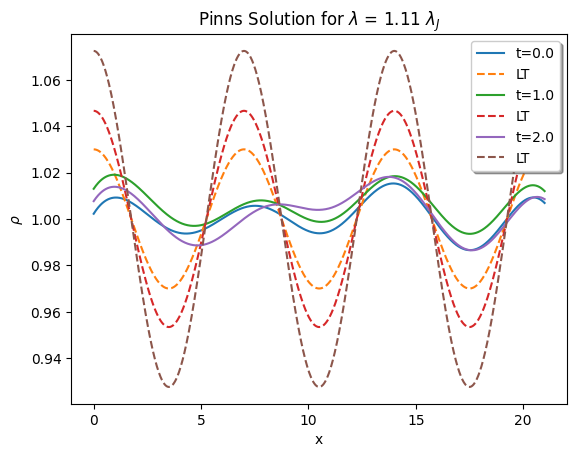

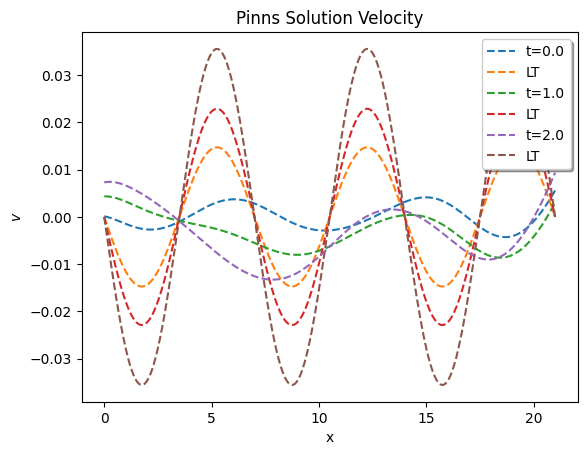

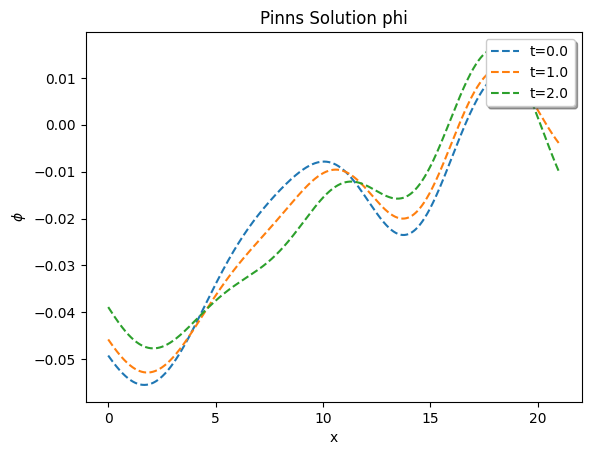

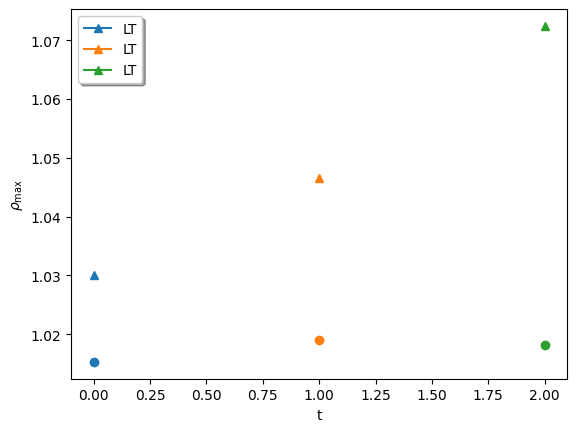

In [26]:
#import Plotting as pt
time_array = np.linspace(0,int(tmax),int(tmax)+1)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax ## required for plotting
plot_function(net,time_array,initial_params,velocity=True,isplot =True)

In [ ]:
'''import LAX as LAX
import numpy as np

## Parameters for the LAX method    
nu = 0.5            # COURANT number
N = 1000            # number of grid points

import time

# start = time.time()
# # t = 1          # time till integrate
# # LAX.lax_solution1D(t,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True)
# end = time.time()
# print("Total time = {} sec for N= {}".format(end - start,N))


time_array = np.asarray([0.5,1.5,2.5])
for time in time_array:
    LAX.lax_solution1D(time,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True,animation=None)'''

<>:31: SyntaxWarning: invalid escape sequence '\%'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\%'
<>:72: SyntaxWarning: invalid escape sequence '\e'
C:\Users\tirth\AppData\Local\Temp\ipykernel_132312\3220452113.py:31: SyntaxWarning: invalid escape sequence '\%'
  '''axes[1][j].plot(x,(rho_pred0[:,0]- rho)/((rho_pred0[:,0]+ rho)/2)*100,color = 'black',linewidth=1,label="FD")
C:\Users\tirth\AppData\Local\Temp\ipykernel_132312\3220452113.py:72: SyntaxWarning: invalid escape sequence '\e'
  '''axes[3][j].plot(x,(v_pred0[:,0]+1- (v+1))/((v_pred0[:,0]+1+ v+1)/2)*100,color = 'black',linewidth=1,label="FD")
C:\Users\tirth\AppData\Local\Temp\ipykernel_132312\3220452113.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
C:\Users\tirth\A

Plotting at t= 0.5
(1000, 1)
Plotting at t= 1.5
(1000, 1)
Plotting at t= 2.5
(1000, 1)


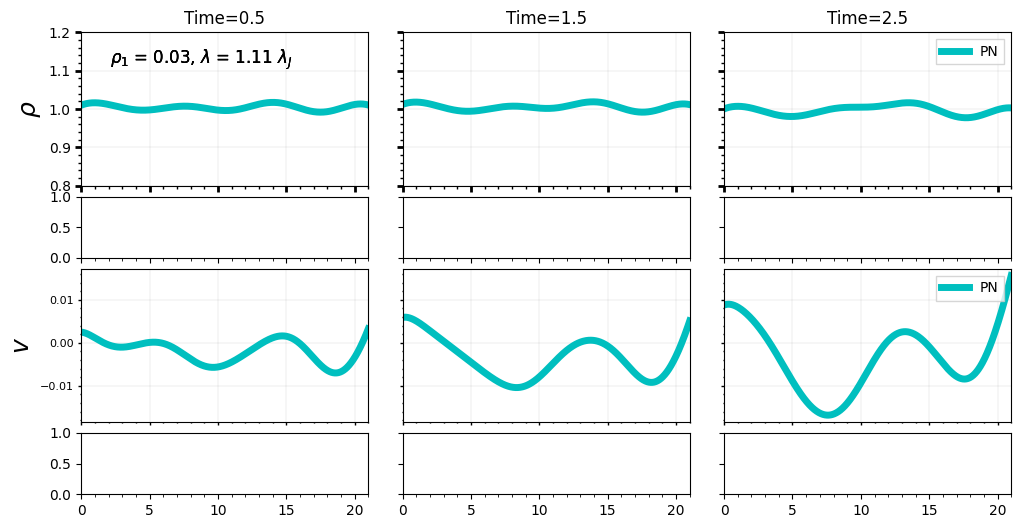

In [27]:
plt.style.use('default')
plt.rc('grid', linestyle='-', color='black', linewidth=0.05)
time_array = np.asarray([0.5,1.5,2.5])
fig, axes = plt.subplots(4, 3, sharex=True,  sharey='row',figsize=(12,6),gridspec_kw={'width_ratios':[1,1,1], 'height_ratios':[3,1.2,3,1.2]})
plt.subplots_adjust(wspace=0.12, hspace=0.1)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax ## Params for pl
for time,j in zip(time_array,range(3)):
    
    #x,rho,v,phi,n,rho_LT,rho_LT_max,rho_max,v_LT= LAX.lax_solution1D(time,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = False,comparison = True)
    X,rho_pred0,v_pred0,phi_pred0,rho_max_PN,rho_theory = plot_function(net,time,initial_params,velocity=True,isplot = False, animation=True)
    axes[0][j].plot(X,rho_pred0,color='c',linewidth=5,label="PN")    
    #axes[0][j].plot(X,rho_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    #axes[0][j].plot(x,rho,linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    axes[0][j].set_xlim(xmin,xmax)
    
    axes[0][j].set_title("Time={}".format(round(time,2)))
    axes[0][0].set_ylabel(r"$\rho$",fontsize = 18)
    # axes[0][j].set_xlabel("x",fontsize = 18)
    axes[0][j].grid("True")
    axes[0][j].minorticks_on()
    axes[0][j].tick_params(labelsize=10)
    axes[0][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[0][j].tick_params(axis='both', which='minor',length=2, width=1)
    limu = 1.2*rho_o
    liml = .8*rho_o
    axes[0][j].set_ylim(liml,limu)
    axes[0][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    axes[0][0].text(0.42, 0.82, r"$\rho_1$ = {}, $\lambda$ = {} $\lambda_J$ ".format(rho_1,round(lam/(2*np.pi),2)),fontsize = 12, horizontalalignment='center', verticalalignment='center', transform=axes[0][0].transAxes) 

    
    '''axes[1][j].plot(x,(rho_pred0[:,0]- rho)/((rho_pred0[:,0]+ rho)/2)*100,color = 'black',linewidth=1,label="FD")
    # axes[1][j].plot(x,(rho_pred0.flatten()-rho_LT.flatten())/((rho_pred0.flatten()+ rho_LT.flatten())/2)*100,color = 'firebrick',linestyle='dashed',linewidth=1,label="LT")
    # axes[1][j].plot(x,(rho_pred0[:,0]- rho[n-1,:])/((rho_pred0[:,0]+ rho[n-1,:])/2)*100,color = 'k',linewidth=1,label="FD")
    #axes[1][j].plot(x,(rho_pred0[:,0]-rho_LT)/((rho_pred0[:,0]+ rho_LT)/2)*100,color = 'b',linewidth=1,label="LT")
    axes[1][j].set_xlabel("x",fontsize = 18)
    axes[1][j].grid("True")
    axes[1][j].minorticks_on()
    axes[1][j].tick_params(labelsize=10)
    axes[1][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[1][j].tick_params(axis='both', which='minor',length=2, width=1.)
    axes[1][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    # axes[1][0].set_ylabel(r"$\rho_{PN}- \rho_{FD or LT}/(0.5 (\times\rho_{PN}+ \rho_{FD or LT}))$",fontsize = 10)
    axes[1][j].set_ylim(-2.0,2.0)
    axes[1][j].set_xlim(xmin,xmax)
    axes[1][0].set_ylabel(r"Rel misfit $\%$ ",fontsize = 14)'''
    
    
    ### VELOCITY PART ######
   
    axes[2][j].plot(X,v_pred0,color='c',linewidth=5,label="PN")    
    #axes[2][j].plot(X,v_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    #axes[2][j].plot(x,v,linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    
    
    # axes[3][j].set_title("Time={}".format(round(time,2)))
    axes[2][0].set_ylabel(r"$v$",fontsize = 18)
    # axes[0][j].set_xlabel("x",fontsize = 18)
    axes[2][j].grid("True")
    axes[2][j].minorticks_on()
    axes[2][j].tick_params(labelsize=8)
    axes[2][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[2][j].tick_params(axis='both', which='minor',length=1, width=1)
    # limu = 1.15*v_o
    # liml = .85*v_o
    # axes[0][j].set_ylim(liml,limu)
    axes[2][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    
#     axes[2][j].set_xlim(xmin,xmax)
#     axes[2][j].set_ylim(-0.6,0.6)
    
    
    '''axes[3][j].plot(x,(v_pred0[:,0]+1- (v+1))/((v_pred0[:,0]+1+ v+1)/2)*100,color = 'black',linewidth=1,label="FD")
    axes[3][j].plot(x,(v_pred0[:,0]+1- (v_LT+1))/((v_pred0[:,0]+1+ (v_LT+1))/2)*100,color = 'b',linewidth=1,label="LT")
    axes[3][j].set_xlabel("x",fontsize = 18)
    axes[3][j].grid("True")
    axes[3][j].minorticks_on()
    axes[3][j].tick_params(labelsize=8)
    axes[3][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[3][j].tick_params(axis='both', which='minor',length=1, width=1.)
    axes[3][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    # axes[1][0].set_ylabel(r"$\rho_{PN}- \rho_{FD or LT}/(0.5 (\times\rho_{PN}+ \rho_{FD or LT}))$",fontsize = 10)
    axes[3][0].set_ylabel(r"$\epsilon$ ",fontsize = 18)
    axes[3][j].set_ylim(-1,1)
    axes[3][j].set_xlim(xmin,xmax)'''
    
    
#plt.savefig(output_folder+'/complete'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=500,bbox_inches = 'tight')

# plt.show()
 